# Quantitative Finance Lab: Portfolio Optimization
In this notebook, we calculate the efficient frontiers, Minimum Variance Portfolios, and analyze the impact of a risk-free asset and transaction costs.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Loading and Preprocessing
file_path = 'Lab3-students.xlsx'
try:
    dati = pd.read_excel(file_path, sheet_name=1)

    # Nomi delle colonne corretti
    prezzi_amazon = dati['AMAZON.COM'].values
    prezzi_facebook = dati['FACEBOOK CLASS A'].values
    prezzi_apple = dati['APPLE'].values

    # Gross daily returns, chronological order
    rend_amazon = (prezzi_amazon[:-1] / prezzi_amazon[1:])[::-1]
    rend_facebook = (prezzi_facebook[:-1] / prezzi_facebook[1:])[::-1]
    rend_apple = (prezzi_apple[:-1] / prezzi_apple[1:])[::-1]

    mu_range = np.linspace(1, 1.002, 200)
    uno2 = np.ones(2)
    uno3 = np.ones(3)
except FileNotFoundError:
    print("Dataset not found. Please upload 'Lab3-students.xlsx'.")

## Frontier A & B: Two-Asset Portfolios
We build the efficient frontiers for Amazon & Facebook (A) and Facebook & Apple (B), and find their Minimum Variance Portfolios.

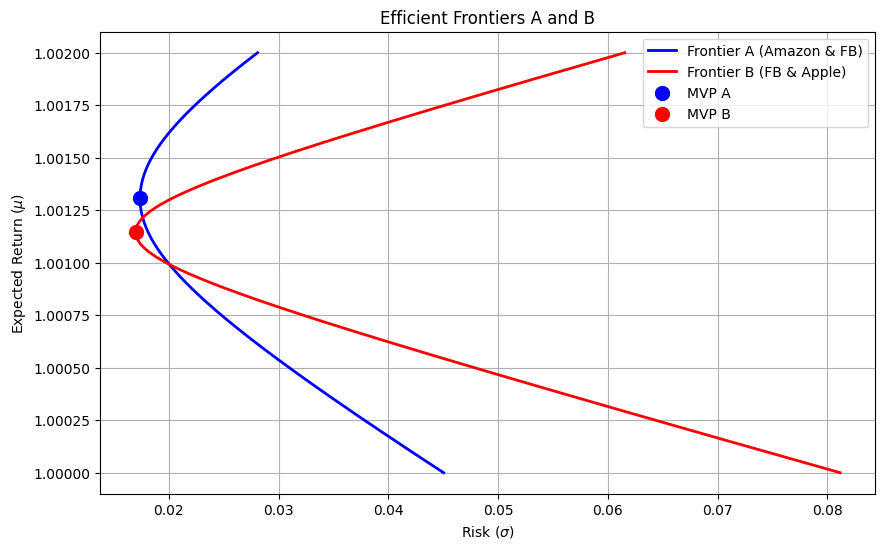

In [4]:
if 'dati' in locals():
    def calc_frontier_params(R, uno):
        mu = np.mean(R, axis=0)
        V = np.cov(R, rowvar=False)
        Vi = np.linalg.inv(V)

        A = uno.T @ Vi @ mu
        B = mu.T @ Vi @ mu
        C = uno.T @ Vi @ uno
        D = B * C - A**2

        g = (B * (Vi @ uno) - A * (Vi @ mu)) / D
        h = (C * (Vi @ mu) - A * (Vi @ uno)) / D

        w_mvp = (Vi @ uno) / C
        mu_mvp = mu.T @ w_mvp
        sigma_mvp = np.sqrt(w_mvp.T @ V @ w_mvp)

        return V, g, h, w_mvp, mu_mvp, sigma_mvp

    # Frontier A: Amazon & Facebook
    R_A = np.column_stack((rend_amazon, rend_facebook))
    V_A, g_A, h_A, w_mvp_A, mu_mvp_A, sigma_mvp_A = calc_frontier_params(R_A, uno2)
    sigma_A = [np.sqrt((g_A + h_A*m).T @ V_A @ (g_A + h_A*m)) for m in mu_range]

    # Frontier B: Facebook & Apple
    R_B = np.column_stack((rend_facebook, rend_apple))
    V_B, g_B, h_B, w_mvp_B, mu_mvp_B, sigma_mvp_B = calc_frontier_params(R_B, uno2)
    sigma_B = [np.sqrt((g_B + h_B*m).T @ V_B @ (g_B + h_B*m)) for m in mu_range]

    plt.figure(figsize=(10, 6))
    plt.plot(sigma_A, mu_range, 'b-', linewidth=2, label='Frontier A (Amazon & FB)')
    plt.plot(sigma_B, mu_range, 'r-', linewidth=2, label='Frontier B (FB & Apple)')
    plt.scatter(sigma_mvp_A, mu_mvp_A, color='blue', s=100, label='MVP A', zorder=5)
    plt.scatter(sigma_mvp_B, mu_mvp_B, color='red', s=100, label='MVP B', zorder=5)

    plt.xlabel(r'Risk ($\sigma$)')
    plt.ylabel(r'Expected Return ($\mu$)')
    plt.title('Efficient Frontiers A and B')
    plt.legend()
    plt.grid(True)
    plt.show()

## Frontier C: Three-Asset Portfolio
Adding a third asset improves diversification, shifting the Minimum Variance Portfolio further left, thus reducing overall portfolio risk.

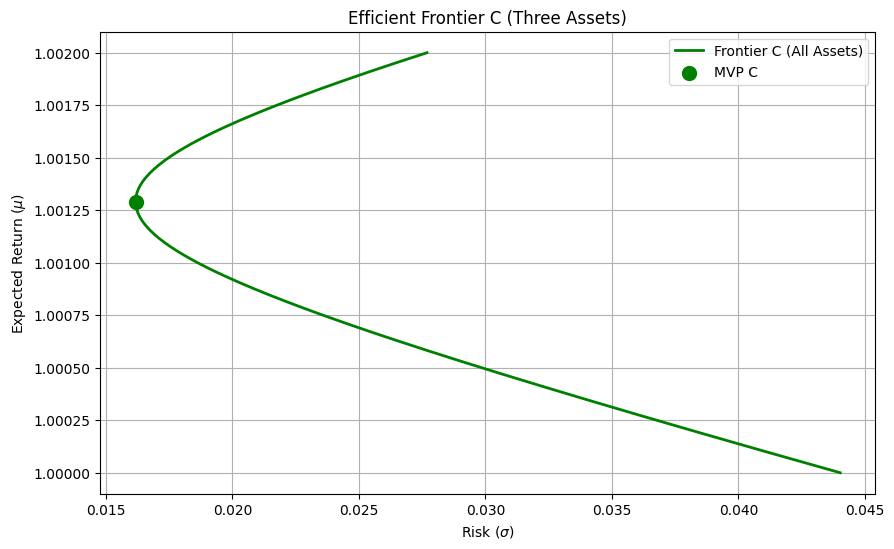

In [5]:
if 'dati' in locals():
    # Frontier C: All three assets
    R_C = np.column_stack((rend_amazon, rend_facebook, rend_apple))
    V_C, g_C, h_C, w_mvp_C, mu_mvp_C, sigma_mvp_C = calc_frontier_params(R_C, uno3)
    sigma_C = [np.sqrt((g_C + h_C*m).T @ V_C @ (g_C + h_C*m)) for m in mu_range]

    plt.figure(figsize=(10, 6))
    plt.plot(sigma_C, mu_range, 'g-', linewidth=2, label='Frontier C (All Assets)')
    plt.scatter(sigma_mvp_C, mu_mvp_C, color='green', s=100, label='MVP C', zorder=5)

    plt.xlabel(r'Risk ($\sigma$)')
    plt.ylabel(r'Expected Return ($\mu$)')
    plt.title('Efficient Frontier C (Three Assets)')
    plt.legend()
    plt.grid(True)
    plt.show()

## Risk-Free Asset and Transaction Costs
Here we calculate the optimal portfolio incorporating a risk-free asset with a daily rate. Finally, we implement a penalty factor for transaction costs to observe how it mitigates extreme weights and short-selling.

In [6]:
if 'dati' in locals():
    # Optimal Portfolio with Risk-Free Asset
    avers = 0.002
    rf_giorn = 1.01 ** (1/252)
    mu_C = np.mean(R_C, axis=0)

    exc_C = mu_C - (rf_giorn * uno3)
    pesi_risk = (1/avers) * np.linalg.inv(V_C) @ exc_C
    peso_rf = 1 - np.sum(pesi_risk)

    mu_ott = rf_giorn + exc_C.T @ pesi_risk
    sigma_ott = np.sqrt(pesi_risk.T @ V_C @ pesi_risk)

    print("--- Optimal Portfolio with Risk-Free Asset ---")
    print(f"Amazon Weight: {pesi_risk[0]:.6f}")
    print(f"Facebook Weight: {pesi_risk[1]:.6f}")
    print(f"Apple Weight: {pesi_risk[2]:.6f}")
    print(f"Risk-Free Weight: {peso_rf:.6f}")
    print(f"Expected Return (mu): {mu_ott:.6f}, Risk (sigma): {sigma_ott:.6f}\n")

    # Transaction Costs Optimization
    alpha = 3
    w0 = np.array([1/3, 1/3, 1/3])
    Lambda = np.diag([0.003, 0.003, 0.001])

    H = alpha * V_C + Lambda
    mu_til = mu_C + Lambda @ w0

    H_inv = np.linalg.inv(H)
    lam = (uno3.T @ (H_inv @ mu_til) - 1) / (uno3.T @ (H_inv @ uno3))
    w_ott5 = H_inv @ (mu_til - lam * uno3)

    print("--- Optimal Portfolio with Transaction Costs ---")
    print(f"Amazon Weight = {w_ott5[0]:.6f}")
    print(f"Facebook Weight = {w_ott5[1]:.6f}")
    print(f"Apple Weight = {w_ott5[2]:.6f}")
    print(f"Expected Return = {w_ott5.T @ mu_C:.6f}")
    print(f"Variance = {w_ott5.T @ V_C @ w_ott5:.6f}")

--- Optimal Portfolio with Risk-Free Asset ---
Amazon Weight: 1832.298549
Facebook Weight: -357.052472
Apple Weight: 917.884615
Risk-Free Weight: -2392.130692
Expected Return (mu): 4.492712, Risk (sigma): 41.789189

--- Optimal Portfolio with Transaction Costs ---
Amazon Weight = 0.411855
Facebook Weight = 0.238867
Apple Weight = 0.349277
Expected Return = 1.001302
Variance = 0.000263
